# Publication_CSSN_Fig4_LLM
Prepare three technology-specific datasets for later LLM stance classification.
Goal: one CCUS/CCS dataset, one biofuels dataset, and one hydrogen dataset.

The input sheet has been manually prepared by Tommy on the 24th of July.

Author: Charlotte Bez

Date: 27/07/2026


In [10]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
import os
import re
import numpy as np
import pandas as pd
from collections import defaultdict

In [11]:
CORPUS_A = r"C:\Users\charlott\Dropbox (Personal)\CSSN_Projects\02_Data\3_Final\df_a_airtable.xlsx"
CORPUS_B = r"C:\Users\charlott\Dropbox (Personal)\CSSN_Projects\02_Data\3_Final\df_b_airtable_reconciled_NER.xlsx"
# `file_path` (the MAXQDA workbook) is already defined earlier in the notebook.

corpus_a = pd.read_excel(CORPUS_A)
corpus_b = pd.read_excel(CORPUS_B)

df = pd.concat([corpus_a, corpus_b], ignore_index=True)

# --- 2. Define umbrella category keyword sets (lowercase) ---
ccus_keywords = {
    "ccs", "ccus", "carbon capture", "carbon capture and storage",
    "carbon capture, utilization", "carbon capture, utilization, and storage",
    "carbon capture, utilization and storage",
    "carbon storage", "carbon dioxide removal", "cdr",
    "direct air capture", "dac"
}

biofuel_keywords = {
    "biofuel", "biodiesel", "algae", "bioenergy",
    "sustainable aviation fuel"
}

hydrogen_keywords = {
    "hydrogen", "ammonia"
}

In [ ]:
def split_tags(cell):
    if pd.isna(cell):
        return set()
    return {tag.strip().lower() for tag in str(cell).split(";") if tag.strip()}

df["_tags"] = df["Keyword Climate/Energy"].apply(split_tags)

# --- Flag each umbrella category if any overlap exists ---
df["CCUS"]     = df["_tags"].apply(lambda tags: bool(tags & ccus_keywords))
df["Biofuels"] = df["_tags"].apply(lambda tags: bool(tags & biofuel_keywords))
df["Hydrogen"] = df["_tags"].apply(lambda tags: bool(tags & hydrogen_keywords))

df["_tags"] = df["Keyword Climate/Energy"].apply(split_tags)

print(df[["CCUS", "Biofuels", "Hydrogen"]].sum())
print()


CCUS        442
Biofuels    146
Hydrogen    224
dtype: int64



In [14]:
# --- Build regex patterns from keyword sets (word-boundary, case-insensitive) ---
def build_pattern(keywords):
    # sort longest-first so multi-word phrases aren't shadowed by short substrings
    escaped = sorted((re.escape(k) for k in keywords), key=len, reverse=True)
    return re.compile(r"\b(" + "|".join(escaped) + r")\b", flags=re.IGNORECASE)

ccus_pattern     = build_pattern(ccus_keywords)
biofuel_pattern  = build_pattern(biofuel_keywords)
hydrogen_pattern = build_pattern(hydrogen_keywords)

# --- Search "File Content" column ---
content = df["File Content"].fillna("")

df["CCUS_in_content"]     = content.str.contains(ccus_pattern)
df["Biofuels_in_content"] = content.str.contains(biofuel_pattern)
df["Hydrogen_in_content"] = content.str.contains(hydrogen_pattern)

# --- Summary counts (files can count toward more than one category) ---
print(df[["CCUS_in_content", "Biofuels_in_content", "Hydrogen_in_content"]].sum())
print()

# --- Optional: how many categories each file mentions (0-3) ---
df["n_categories_in_content"] = df[
    ["CCUS_in_content", "Biofuels_in_content", "Hydrogen_in_content"]
].sum(axis=1)

print("Distribution of # umbrella categories mentioned per file:")
print(df["n_categories_in_content"].value_counts().sort_index())

C:\Users\charlott\AppData\Local\Temp\ipykernel_3428\2757078446.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["CCUS_in_content"]     = content.str.contains(ccus_pattern)
C:\Users\charlott\AppData\Local\Temp\ipykernel_3428\2757078446.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["Biofuels_in_content"] = content.str.contains(biofuel_pattern)
C:\Users\charlott\AppData\Local\Temp\ipykernel_3428\2757078446.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["Hydrogen_in_content"] = content.str.contains(hydrogen_pattern)


CCUS_in_content        441
Biofuels_in_content    151
Hydrogen_in_content    224
dtype: int64

Distribution of # umbrella categories mentioned per file:
n_categories_in_content
0    4180
1     283
2     205
3      41
Name: count, dtype: int64


In [15]:
# count of how many times each keyword appears (not just presence/absence
df["CCUS_in_content"]     = content.str.count(ccus_pattern)
df["Biofuels_in_content"] = content.str.count(biofuel_pattern)
df["Hydrogen_in_content"] = content.str.count(hydrogen_pattern)

# --- Summary counts (files can count toward more than one category) ---
print(df[["CCUS_in_content", "Biofuels_in_content", "Hydrogen_in_content"]].sum())
print()


CCUS_in_content        2292
Biofuels_in_content     456
Hydrogen_in_content     785
dtype: int64



In [16]:
# Now we're moving from "does the file mention it" to "show me the actual sentence(s) around each mention"
patterns = {
    "CCUS": ccus_pattern,
    "Biofuels": biofuel_pattern,
    "Hydrogen": hydrogen_pattern,
}

WINDOW = 300  # characters before/after the match — adjust as needed

def extract_snippets(text, pattern, window=WINDOW):
    """Return list of (matched_keyword, snippet, start_pos) for every match in text."""
    if not isinstance(text, str) or not text:
        return []
    results = []
    for m in pattern.finditer(text):
        start, end = m.start(), m.end()
        snippet_start = max(0, start - window)
        snippet_end = min(len(text), end + window)
        snippet = text[snippet_start:snippet_end].strip()
        # add ellipses to signal truncation
        prefix = "..." if snippet_start > 0 else ""
        suffix = "..." if snippet_end < len(text) else ""
        snippet = f"{prefix}{snippet}{suffix}"
        results.append((m.group(0), snippet, start))
    return results

doc_id_col = "Document ID"

rows = []
for idx, row in df.iterrows():
    text = row["File Content"]
    doc_id = row[doc_id_col] if doc_id_col else idx

    for category, pattern in patterns.items():
        matches = extract_snippets(text, pattern)
        for keyword, snippet, pos in matches:
            rows.append({
                "doc_id": doc_id,
                "row_index": idx,
                "category": category,
                "matched_keyword": keyword,
                "match_position": pos,
                "snippet": snippet,
            })

snippets_df = pd.DataFrame(rows)

# --- Sanity checks ---
print("Total snippets extracted:", len(snippets_df))
print()
print("Snippets per category:")
print(snippets_df["category"].value_counts())
print()
print("Snippets per document (top 10 most-mentioned docs):")
print(
    snippets_df.groupby(["doc_id", "category"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Total snippets extracted: 3533

Snippets per category:
category
CCUS        2292
Hydrogen     785
Biofuels     456
Name: count, dtype: int64

Snippets per document (top 10 most-mentioned docs):
doc_id              category
bp_24               CCUS        124
BPA_HCOR_00058113   CCUS         92
BPA_HCOR_00049634   CCUS         73
BPA_HCOR_00037840   CCUS         67
exxonmobil_sept_18  Biofuels     53
exxonmobil_5        CCUS         49
shell_15            CCUS         43
BPA_HCOR_00186791   CCUS         40
EM-HCOR3-00604560   Biofuels     38
BPA_HCOR_00126554   CCUS         37
dtype: int64


In [ ]:
# for tommy, to try with clara

# --- Filter to Hydrogen snippets only ---
hydrogen_snippets = snippets_df[snippets_df["category"] == "Hydrogen"].copy()
print(f"Hydrogen snippets: {len(hydrogen_snippets)}")

# --- Write to a single txt file, one snippet per entry, with doc/context info ---
output_path = "hydrogen_snippets_input_clara.txt"

with open("hydrogen_snippets_input_clara.txt", "w", encoding="utf-8") as f:
    for snippet in hydrogen_snippets["snippet"]:
        f.write(snippet.strip() + "\n\n")

print(f"Saved {len(hydrogen_snippets)} snippets to {output_path}")

Hydrogen snippets: 785
Saved 785 snippets to hydrogen_snippets_input_clara.txt


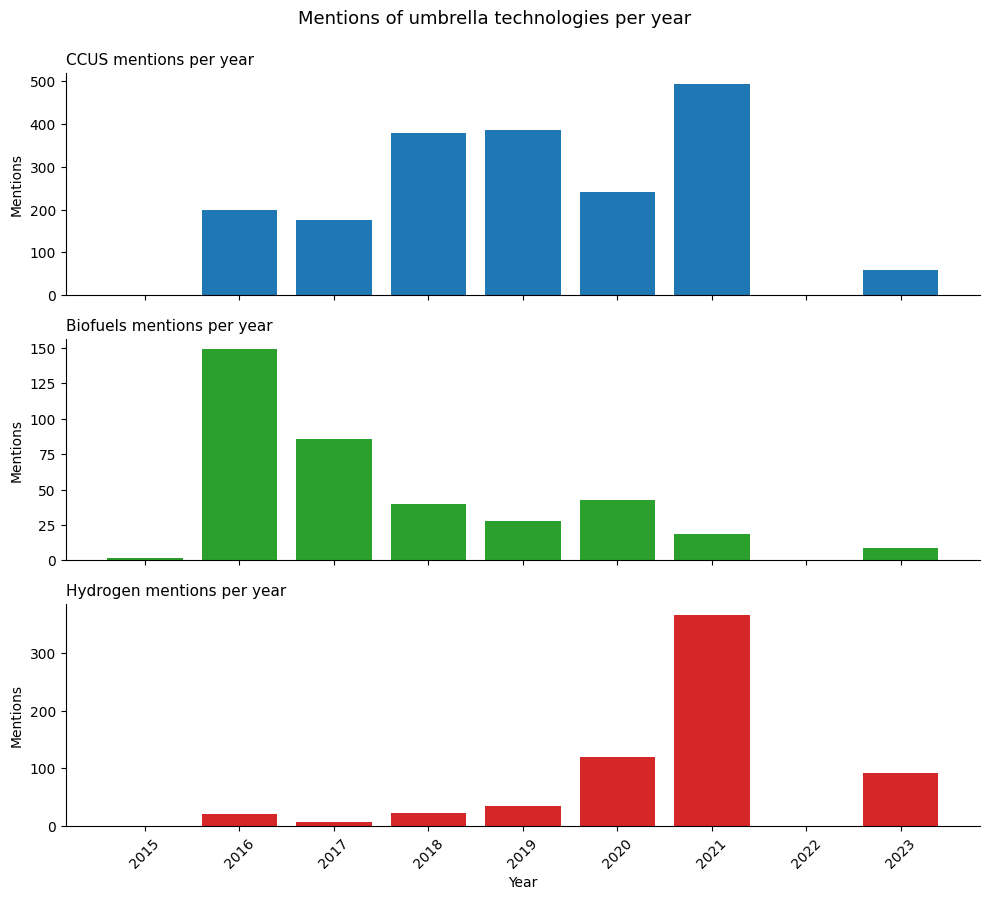

In [118]:
df["Latest Date_parsed"] = pd.to_datetime(df["Latest Date"], format="%m/%d/%Y", errors="coerce")
df["Latest Year"] = df["Latest Date_parsed"].dt.year

# --- 2. Map year onto each snippet via row_index ---
snippets_df["year"] = snippets_df["row_index"].map(df["Latest Year"])

# --- 3. Count mentions per year, per category ---
counts = (
    snippets_df.dropna(subset=["year"])
    .groupby(["category", "year"])
    .size()
    .reset_index(name="mentions")
)
counts["year"] = counts["year"].astype(int)

# --- 4. Build a full year range so all panels share the same x-axis ---
all_years = range(counts["year"].min(), counts["year"].max() + 1)

# --- 5. Plot: 3 vertically stacked panels ---
categories = ["CCUS", "Biofuels", "Hydrogen"]
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)

colors = {"CCUS": "#1f77b4", "Biofuels": "#2ca02c", "Hydrogen": "#d62728"}

for ax, cat in zip(axes, categories):
    cat_counts = counts[counts["category"] == cat].set_index("year").reindex(all_years, fill_value=0)
    ax.bar(cat_counts.index, cat_counts["mentions"], color=colors[cat])
    ax.set_title(f"{cat} mentions per year", loc="left", fontsize=11)
    ax.set_ylabel("Mentions")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Year")
axes[-1].set_xticks(list(all_years))
axes[-1].set_xticklabels(list(all_years), rotation=45)

fig.suptitle("Mentions of umbrella technologies per year", fontsize=13, y=0.995)
fig.tight_layout()
plt.savefig("mentions_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
file_path = r'C:\Users\charlott\Dropbox (Personal)\CSSN_Projects\03_Analysis\Figures_KlugGarroBez\discursive_discrepancies_24.07.xlsx'

In [95]:
# Load the hand-coded discursive discrepancies workbook and normalize the key columns.
if not os.path.exists(file_path):
    raise FileNotFoundError(f'Missing workbook: {file_path}')

discursive_df = pd.read_excel(file_path, sheet_name='Data')
print('Loaded discursive_df:', discursive_df.shape)
print('Columns:', discursive_df.columns.tolist())

discursive_df['statement_class'] = (
    discursive_df['statement_class']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({'nan': np.nan})
)
discursive_df['statement_category'] = (
    discursive_df['statement_category']
    .astype(str)
    .str.strip()
    .replace({'nan': np.nan})
)

discursive_df = discursive_df.loc[discursive_df['statement_class'].isin(['confident', 'skeptical'])].copy()
print('Filtered statement classes:', discursive_df['statement_class'].value_counts(dropna=False).to_dict())

prompt_columns = [
    'technology', 'statement_class', 'statement_category',
    'climate_justification', 'snippet_original',
    'MAXQDA_category', 'audience', 'context',
    'company', 'Document ID'
]
prompt_columns = [c for c in prompt_columns if c in discursive_df.columns]
prompt_ready_df = discursive_df[prompt_columns].copy()
prompt_ready_df.to_csv('discursive_prompt_input.csv', index=False)
print('Saved prompt-ready CSV: discursive_prompt_input.csv')
prompt_ready_df.head(10)


Loaded discursive_df: (151, 12)
Columns: ['technology', 'statement_class', 'statement_category', 'climate_justification', 'snippet_original', 'code', 'MAXQDA_category', 'audience', 'context', 'company', 'Document ID', 'Notes']
Filtered statement classes: {'confident': 94, 'skeptical': 57}
Saved prompt-ready CSV: discursive_prompt_input.csv


,technology,statement_class,statement_category,climate_justification,snippet_original,MAXQDA_category,audience,context,company,Document ID
0,"ccus, biofuels",confident,climate positive,net zero,DIRECT AIR CAPTURE AND BIOENERGY WITH CCS ARE ASPECTS OF CCUS that can take industry beyond net-zero GHG emissions to negative emissions.”,SUPPORTS CLIMATE GOALS,external,partner strategy document,BP,BPA_HCOR_00339261
1,"ccus, biofuels",confident,climate positive,low carbon business strategy,"At BP, we’ve been doing our part to hasten the energy transition by building the largest\noperated renewables business of any major oil and gas company (including more than a dozen\nwind farms here in the U.S.); by improving the energy efficiency of our traditional operations\nand products; by developing and marketing lower-carbon biofuels and natural gas; and by\n\n1 (Oil) https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRFPUS2&f=A. (Gas)\nhttps://www.eia.gov/dnav/ng/hist/n9050us2a.htm.\n2 https://www.eia.gov/todayinenergy/detail.php?id=30712\n3 https://www.eia.gov/todayinenergy/detail.php?id=30712\n\n\n\nteaming up with other companies to develop and deploy cutting-edge technologies that can\nhelp us reduce methane emissions and capture, use and store carbon",SUPPORTS CLIMATE GOALS,external,op-ed draft,BP,BPA_HCOR_00029217
2,ccus,confident,"climate positive, cost effective",NaN,o CCUS is the only cost-effective means of achieving deep emissions reductions in \n existing power infrastructure and energy-intensive industries that rely on the \n use of fossil fuels,SUPPORTS CLIMATE GOALS,external,talking points document,BP,bp_14
3,ccus,confident,climate positive,paris,"To meet the Paris goals, we believe the world must take strong action\non a range of fronts:\n\n•\tReducing emissions rather than promoting one energy source as\tthe answer\n\n•\tImproving energy efficiency\n\n•\tDelivering more energy affordably\n\n•\tUsing and deploying new technologies, such as carbon capture,\n\tuse and storage",SUPPORTS CLIMATE GOALS,internal,committee meeting slides,BP,BPA_HCOR_00114332
4,biofuels,confident,climate positive,active player in energy market,"BP is a leader in biofuels. In addition to BP-Bunge Bioenergia - our 50:50 joint bioenergy\n█ ███████ Brazi - we are active in renewable diesel and; biogasp and we have invested in \nFuturum Bioenergy, which has developed a process to convert domestic waste\ninto biobjat-aviation fuel (SAF). In addition, and we are reducing the life \ncycle carbon content-intensity of our fuels by co-processing renewable feedstocks in \nsome refineries.",SUPPORTS CLIMATE GOALS,external,talking points document,BP,BPA_HCOR_00341624
5,hydrogen,confident,climate positive,paris,• BP believes that hydrogen has a critical role to play in achieving the goals of the Paris \nAgreement.,SUPPORTS CLIMATE GOALS,external,talking points document,BP,BPA_HCOR_00341624
6,ccus,confident,climate positive,"net zero, paris, ipcc","• CCUS has a critical role to ~~is likely to play an important role in~~ getting the world \n to net zero. The UK Committee on Climate Change called CCUS ""a necessity not\n an option"".\n Commented [SR18]: Rather than just quoting the UK \n Committee, should we include a quote from IPCC, IEA\n or another respected global organization stressing the \n importance of CCUS in achieving Net Zero\n• CCUS can help the world meet the Paris goals at lower cost. The IPCC has set out scenarios \n in which deployment of CCUS more than halves the cost of limiting temperature rise to 2\n degrees. This is critical in maintaining public and political support for getting to net zero.\n Commented [SR19]: Maybe “is needed” to help the\n world meet the goals at a lower cost\n• CCUS can achieve deep emissions reductions in parts of the economy where using\n renewables is technically or economically unfeasible.\n (, Pos. 336-349)",SUPPORTS CLIMATE GOALS,external,talking points document,BP,BPA_HCOR_00341624
7,ccus,confident,tech prov

Saved: confidence_panels.png


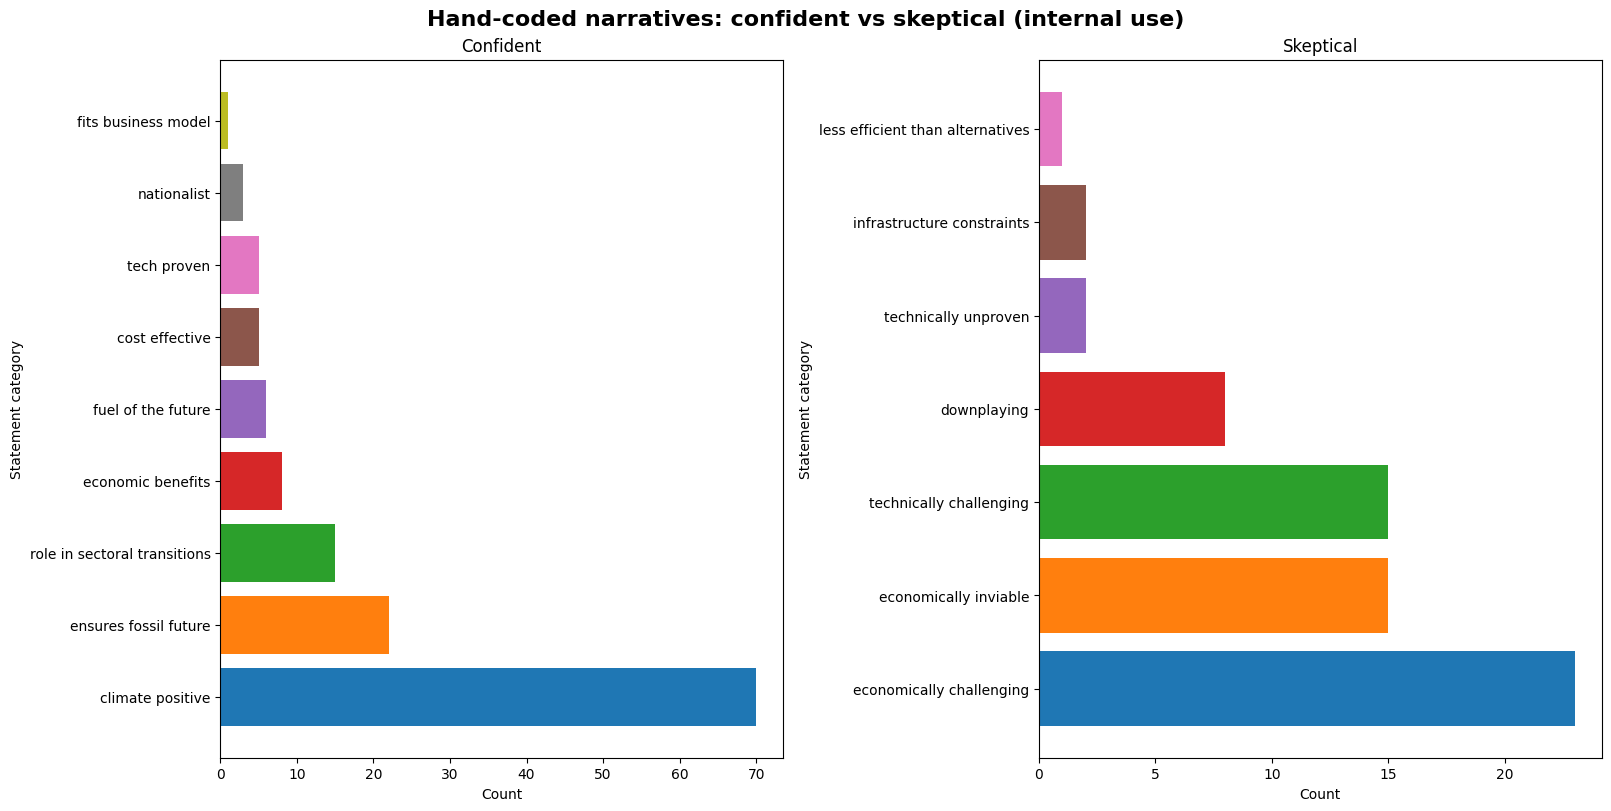

In [96]:
# --- Create two-panel figure for Skeptical vs Confident ---

def plot_confidence_panels(df, save=True, outname='confidence_panels.png'):
    df = df.copy()
    df['statement_class'] = df['statement_class'].str.title()
    classes = ['Confident', 'Skeptical']
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

    for ax, cls in zip(axes, classes):
        subset = df.loc[df['statement_class'] == cls]
        if subset.empty:
            ax.text(0.5, 0.5, f'No data for {cls}', ha='center', va='center', fontsize=14)
            ax.set_axis_off()
            continue

        exploded = (
            subset['statement_category']
            .fillna('Missing')
            .astype(str)
            .str.split(',')
            .explode()
            .str.strip()
            .replace('', 'Missing')
        )
        category_counts = exploded.value_counts()
        ax.barh(category_counts.index, category_counts.values, color=sns.color_palette('tab10', len(category_counts)))
        ax.set_title(cls)
        ax.set_xlabel('Count')
        ax.set_ylabel('Statement category')

    fig.suptitle('Hand-coded narratives: confident vs skeptical (internal use)', fontsize=16, fontweight='bold')
    if save:
        fig.savefig(outname, dpi=200, bbox_inches='tight')
        print('Saved:', outname)
    plt.show()

plot_confidence_panels(prompt_ready_df)


In [97]:
# --- 0. Diagnostic: compare ID formats before merging ---
print("Sample Document ID from discursive_df:")
print(discursive_df['Document ID'].dropna().astype(str).unique()[:10])

bp_ids = df.loc[
    df['Document ID'].astype(str).str.strip().str.startswith('BP'),
    'Document ID'
].dropna().unique()

print(f"Found {len(bp_ids)} Document IDs starting with BP:")
print(bp_ids[:20])

print("\ndtypes -> Document ID:", discursive_df['Document ID'].dtype, "| Document ID:", df['Document ID'].dtype)

Sample Document ID from discursive_df:
['BPA_HCOR_00339261' 'BPA_HCOR_00029217' 'bp_14' 'BPA_HCOR_00114332'
 'BPA_HCOR_00341624' 'BPA_HCOR_00342500' 'BPA_HCOR_00331085'
 'CHEV-117HCOR-0013016' 'CHEV-117HCOR-0010111' 'BPA_HCOR_00050382']
Found 3883 Document IDs starting with BP:
['BPA_HCOR_00018043' 'BPA_HCOR_00018097' 'BPA_HCOR_00018124'
 'BPA_HCOR_00018167' 'BPA_HCOR_00018369' 'BPA_HCOR_00018710'
 'BPA_HCOR_00018714' 'BPA_HCOR_00018762' 'BPA_HCOR_00028087'
 'BPA_HCOR_00028668' 'BPA_HCOR_00028921' 'BPA_HCOR_00028931'
 'BPA_HCOR_00029063' 'BPA_HCOR_00029157' 'BPA_HCOR_00029214'
 'BPA_HCOR_00029217' 'BPA_HCOR_00029988' 'BPA_HCOR_00029996'
 'BPA_HCOR_00030447' 'BPA_HCOR_00032843']

dtypes -> Document ID: object | Document ID: object


In [98]:
# --- 1. Clean IDs on both sides the same way ---
discursive_df['doc_id_clean'] = (
    discursive_df['Document ID'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
)
df['Document ID_clean'] = (
    df['Document ID'].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)
)

# --- 2. Build a lookup table: one row per Document ID, just ID + year ---
year_lookup = (
    df.dropna(subset=['Document ID'])
    .drop_duplicates(subset='Document ID_clean', keep='first')
    [['Document ID_clean', 'Latest Date']]
)

# --- 3. Merge to bring "Latest Date" into discursive_df ---
discursive_df = discursive_df.merge(
    year_lookup,
    left_on='doc_id_clean',
    right_on='Document ID_clean',
    how='left'
).rename(columns={'Latest Date': 'year'})

missing_year = discursive_df['year'].isna().sum()
print(f"Rows with no matching year: {missing_year} out of {len(discursive_df)}")

# --- 4. Show unmatched IDs for inspection ---
unmatched_ids = discursive_df.loc[discursive_df['year'].isna(), 'Document ID'].unique()
print("Unmatched doc_id examples:", unmatched_ids[:20])

Rows with no matching year: 10 out of 151
Unmatched doc_id examples: ['exxonmobil_sept_11' 'shell_1' 'bp_10' 'api_10' 'BPA_HCOR_00270486'
 'CHEV-117HCOR-0009268']


Rows with no matching year: 17 out of 151
Climate positive rows found: 33
Rows going into plot: 38


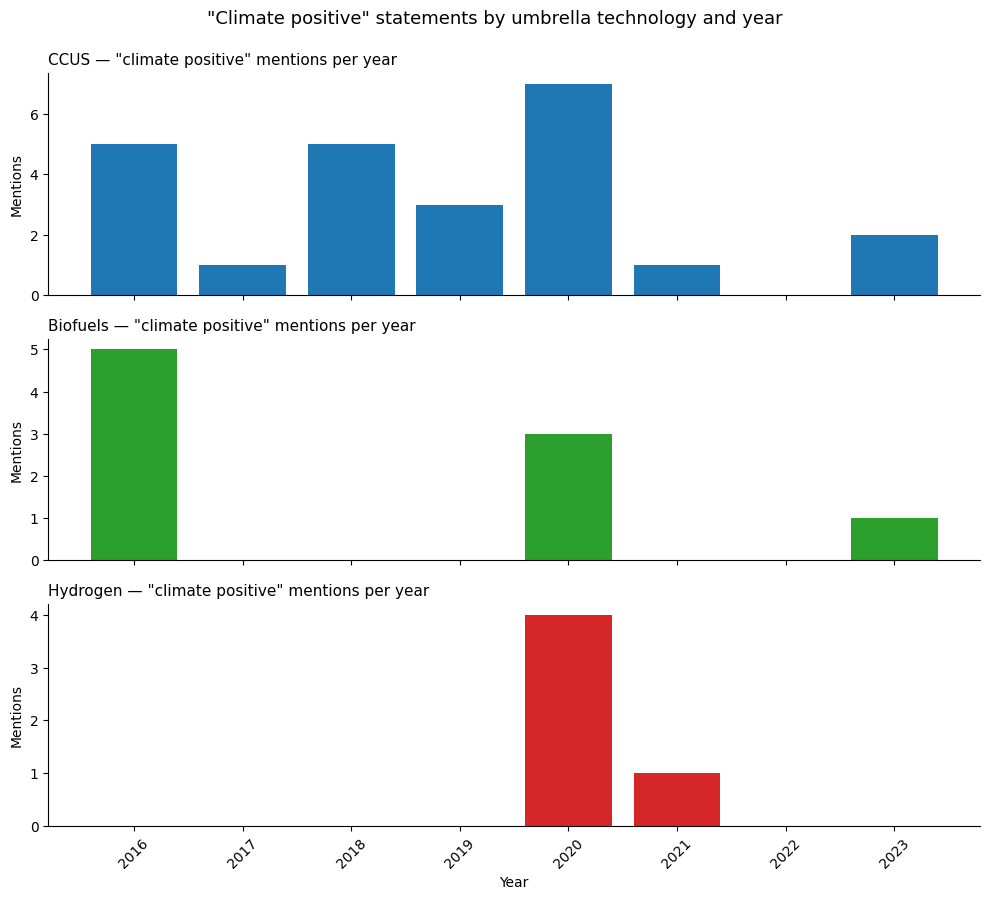

In [101]:
# --- 1. Derive year from "Latest Date" in df ---
df['Latest Date_parsed'] = pd.to_datetime(df['Latest Date'], format='%m/%d/%Y', errors='coerce')
df['Latest Year'] = df['Latest Date_parsed'].dt.year

# --- 2. Clean IDs on both sides ---
discursive_df['Document ID_clean'] = discursive_df['Document ID'].astype(str).str.strip().str.upper()
df['Document ID_clean'] = df['Document ID'].astype(str).str.strip().str.upper()

# --- 3. Build lookup table: one row per Document ID ---
year_lookup = (
    df.dropna(subset=['Document ID'])
    .drop_duplicates(subset='Document ID_clean', keep='first')
    [['Document ID_clean', 'Latest Year']]
)

# --- 4. Merge to bring year into discursive_df ---
discursive_df = discursive_df.drop(columns=[c for c in ['year'] if c in discursive_df.columns])
discursive_df = discursive_df.merge(
    year_lookup, on='Document ID_clean', how='left'
).rename(columns={'Latest Year': 'year'})

missing_year = discursive_df['year'].isna().sum()
print(f"Rows with no matching year: {missing_year} out of {len(discursive_df)}")

# --- 5. Filter to "climate positive" ---
climate_positive_df = discursive_df[
    discursive_df['statement_category'] == 'climate positive'
].copy()
print("Climate positive rows found:", len(climate_positive_df))

# --- 6. Split combined technology values and explode ---
climate_positive_df['technology'] = (
    climate_positive_df['technology'].astype(str).str.strip().str.lower()
)
climate_positive_df['umbrella_list'] = climate_positive_df['technology'].str.split(r'\s*,\s*')
exploded_df = climate_positive_df.explode('umbrella_list')
exploded_df['umbrella_list'] = exploded_df['umbrella_list'].str.strip()

umbrella_display = {'ccus': 'CCUS', 'biofuels': 'Biofuels', 'hydrogen': 'Hydrogen'}
exploded_df['umbrella'] = exploded_df['umbrella_list'].map(umbrella_display)

unmapped = exploded_df[exploded_df['umbrella'].isna()]['umbrella_list'].unique()
if len(unmapped):
    print("Warning: unmapped technology values:", unmapped)

# --- 7. Count mentions per umbrella category per year ---
plot_df = exploded_df.dropna(subset=['umbrella', 'year'])
print(f"Rows going into plot: {len(plot_df)}")

counts = plot_df.groupby(['umbrella', 'year']).size().reset_index(name='mentions')
counts['year'] = counts['year'].astype(int)

all_years = range(int(counts['year'].min()), int(counts['year'].max()) + 1)

# --- 8. Plot: 3 vertically stacked panels ---
categories = ['CCUS', 'Biofuels', 'Hydrogen']
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)
colors = {'CCUS': '#1f77b4', 'Biofuels': '#2ca02c', 'Hydrogen': '#d62728'}

for ax, cat in zip(axes, categories):
    cat_counts = counts[counts['umbrella'] == cat].set_index('year').reindex(all_years, fill_value=0)
    ax.bar(cat_counts.index, cat_counts['mentions'], color=colors[cat])
    ax.set_title(f'{cat} — "climate positive" mentions per year', loc='left', fontsize=11)
    ax.set_ylabel('Mentions')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year')
axes[-1].set_xticks(list(all_years))
axes[-1].set_xticklabels(list(all_years), rotation=45)

fig.suptitle('"Climate positive" statements by umbrella technology and year', fontsize=13, y=0.995)
fig.tight_layout()
plt.savefig('climate_positive_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

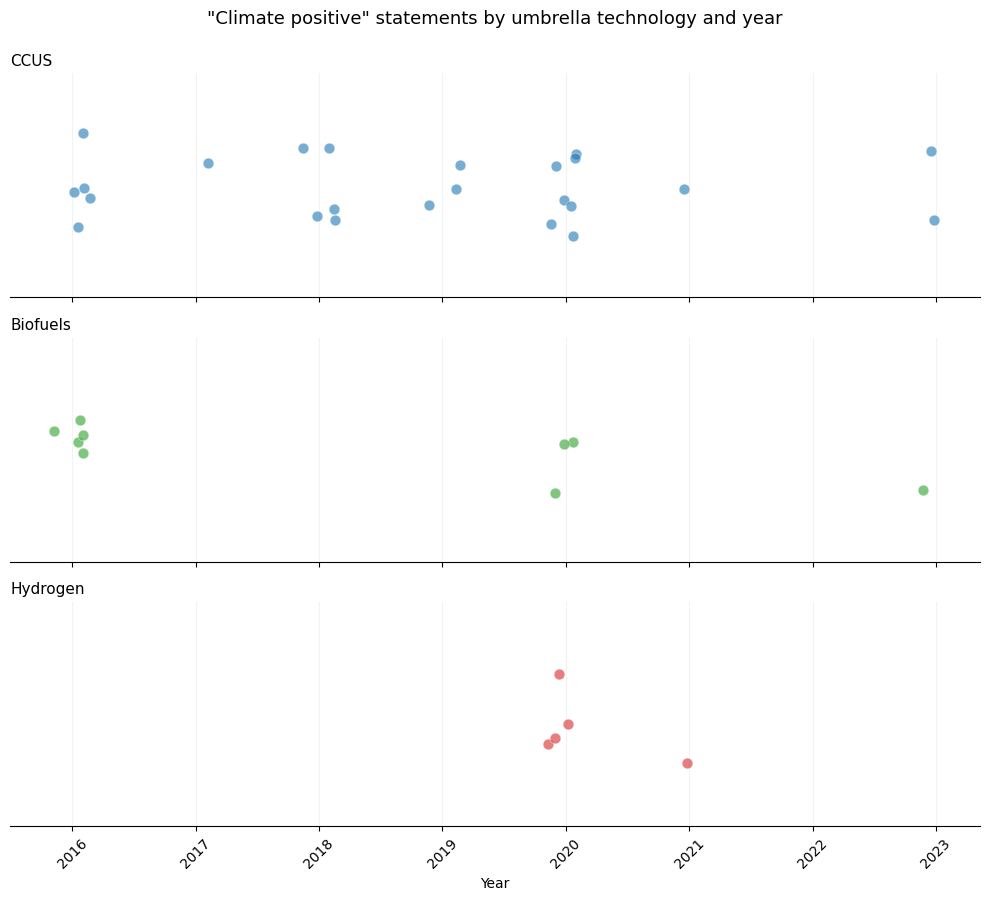

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# --- Reuse plot_df from before: one row per (technology-mention, climate-positive) ---
categories = ['CCUS', 'Biofuels', 'Hydrogen']
colors = {'CCUS': '#1f77b4', 'Biofuels': '#2ca02c', 'Hydrogen': '#d62728'}

all_years = range(int(plot_df['year'].min()), int(plot_df['year'].max()) + 1)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)

rng = np.random.default_rng(42)  # fixed seed so jitter is reproducible

for ax, cat in zip(axes, categories):
    sub = plot_df[plot_df['umbrella'] == cat]

    # jitter x slightly within each year, keep y jittered too for visual spread
    x_jitter = sub['year'] + rng.uniform(-0.15, 0.15, size=len(sub))
    y_jitter = rng.uniform(-1, 1, size=len(sub))

    ax.scatter(
        x_jitter, y_jitter,
        color=colors[cat], alpha=0.6, s=60,
        edgecolor='white', linewidth=0.5
    )

    ax.set_title(f'{cat}', loc='left', fontsize=11)
    ax.set_yticks([])
    ax.set_ylim(-2, 2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # light vertical gridlines per year for readability
    for yr in all_years:
        ax.axvline(yr, color='grey', alpha=0.1, linewidth=0.8)

axes[-1].set_xlabel('Year')
axes[-1].set_xticks(list(all_years))
axes[-1].set_xticklabels(list(all_years), rotation=45)

fig.suptitle('"Climate positive" statements by umbrella technology and year', fontsize=13, y=0.995)
fig.tight_layout()
plt.savefig('climate_positive_stripplot.png', dpi=150, bbox_inches='tight')
plt.show()

Economically challenging rows found: 17
Rows going into plot: 15


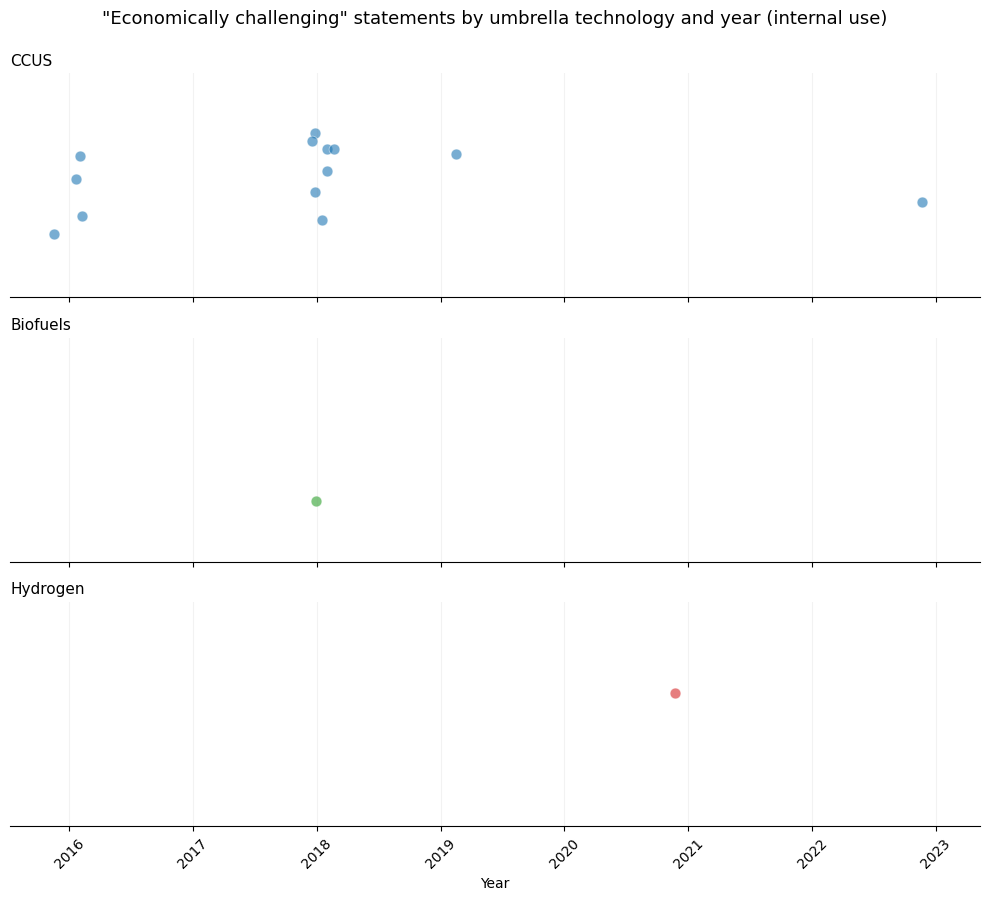

In [108]:
# --- 1. Filter to "economically challenging" ---
econ_challenging_df = discursive_df[
    discursive_df['statement_category'] == 'economically challenging'
].copy()
print("Economically challenging rows found:", len(econ_challenging_df))

# --- 2. Split combined technology values and explode ---
econ_challenging_df['technology'] = (
    econ_challenging_df['technology'].astype(str).str.strip().str.lower()
)
econ_challenging_df['umbrella_list'] = econ_challenging_df['technology'].str.split(r'\s*,\s*')
exploded_econ_df = econ_challenging_df.explode('umbrella_list')
exploded_econ_df['umbrella_list'] = exploded_econ_df['umbrella_list'].str.strip()

umbrella_display = {'ccus': 'CCUS', 'biofuels': 'Biofuels', 'hydrogen': 'Hydrogen'}
exploded_econ_df['umbrella'] = exploded_econ_df['umbrella_list'].map(umbrella_display)

unmapped = exploded_econ_df[exploded_econ_df['umbrella'].isna()]['umbrella_list'].unique()
if len(unmapped):
    print("Warning: unmapped technology values:", unmapped)

# --- 3. Drop missing umbrella/year ---
econ_plot_df = exploded_econ_df.dropna(subset=['umbrella', 'year'])
print(f"Rows going into plot: {len(econ_plot_df)}")

# --- 4. Strip plot ---
categories = ['CCUS', 'Biofuels', 'Hydrogen']
colors = {'CCUS': '#1f77b4', 'Biofuels': '#2ca02c', 'Hydrogen': '#d62728'}

all_years = range(int(econ_plot_df['year'].min()), int(econ_plot_df['year'].max()) + 1)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9), sharex=True)
rng = np.random.default_rng(42)

for ax, cat in zip(axes, categories):
    sub = econ_plot_df[econ_plot_df['umbrella'] == cat]

    x_jitter = sub['year'] + rng.uniform(-0.15, 0.15, size=len(sub))
    y_jitter = rng.uniform(-1, 1, size=len(sub))

    ax.scatter(
        x_jitter, y_jitter,
        color=colors[cat], alpha=0.6, s=60,
        edgecolor='white', linewidth=0.5
    )

    ax.set_title(f'{cat}', loc='left', fontsize=11)
    ax.set_yticks([])
    ax.set_ylim(-2, 2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    for yr in all_years:
        ax.axvline(yr, color='grey', alpha=0.1, linewidth=0.8)

axes[-1].set_xlabel('Year')
axes[-1].set_xticks(list(all_years))
axes[-1].set_xticklabels(list(all_years), rotation=45)

fig.suptitle('"Economically challenging" statements by umbrella technology and year (internal use)', fontsize=13, y=0.995)
fig.tight_layout()
plt.savefig('economically_challenging_stripplot.png', dpi=150, bbox_inches='tight')
plt.show()

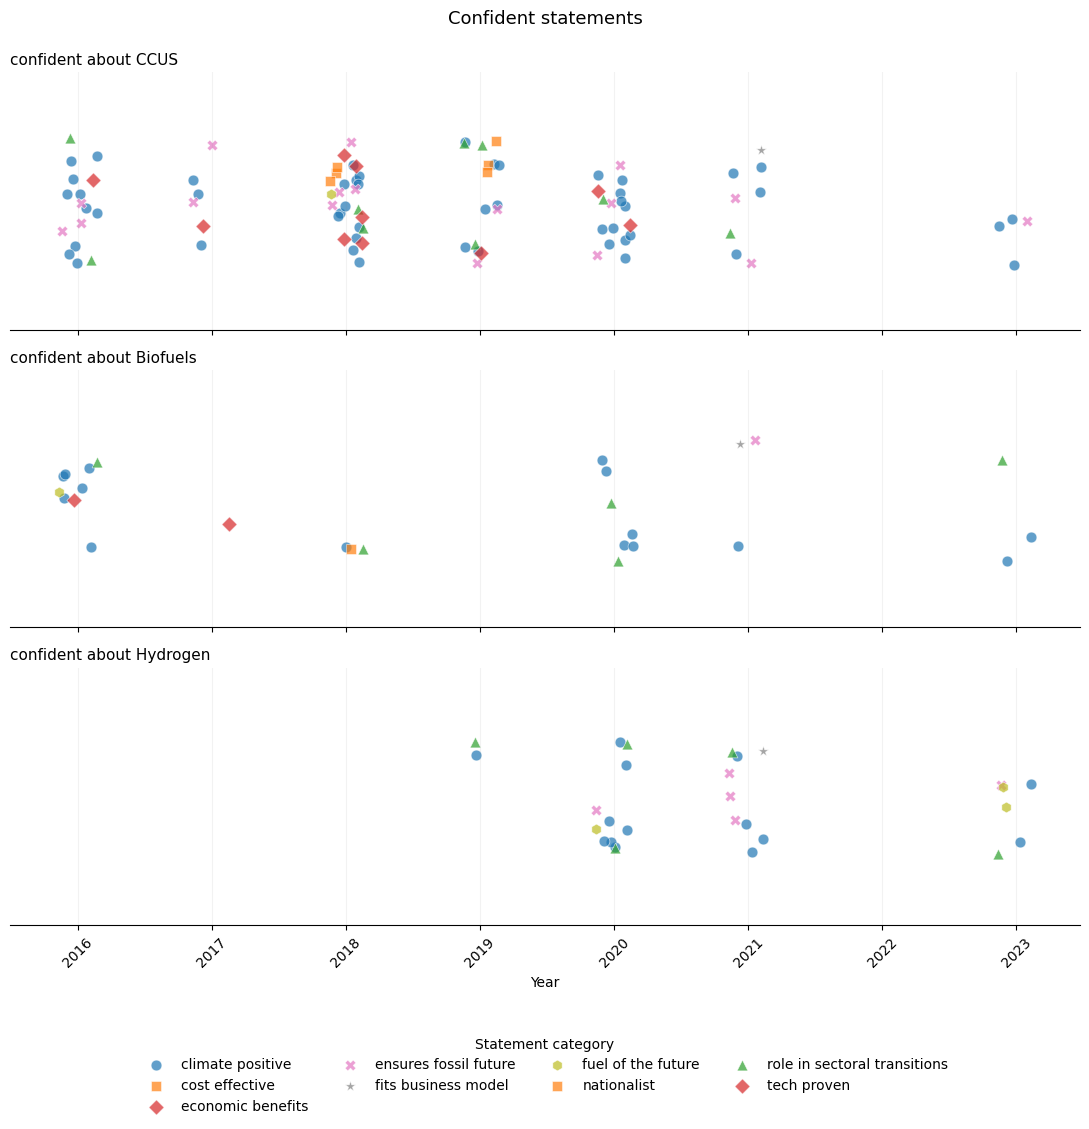

Saved: statements_confident_by_year.png


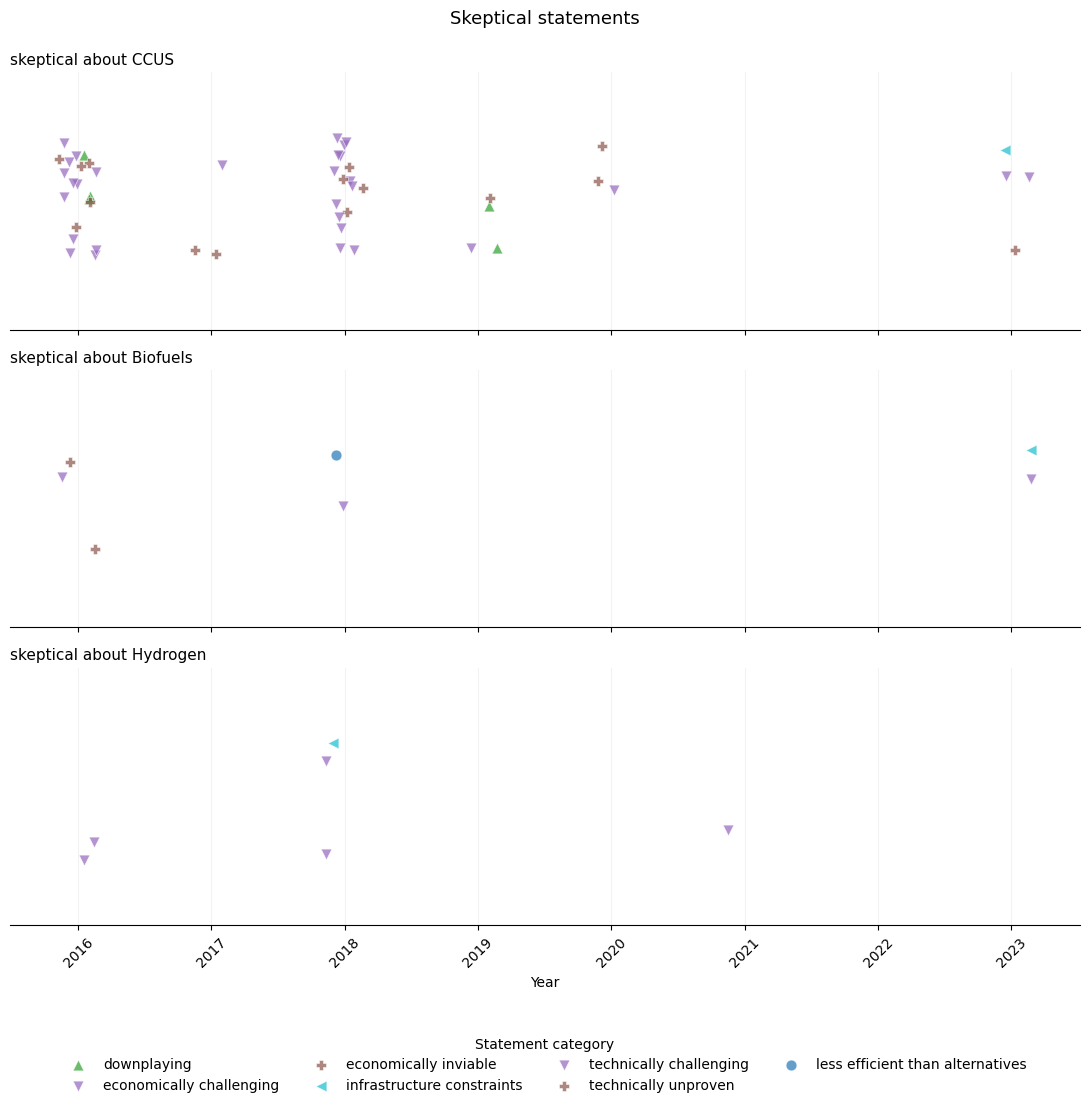

Saved: statements_skeptical_by_year.png


In [125]:
# --- 1. Build the exploded, umbrella-mapped dataset ONCE for all subnarratives ---
base_df = discursive_df.dropna(subset=['statement_category', 'statement_class', 'year']).copy()

base_df['technology'] = base_df['technology'].astype(str).str.strip().str.lower()
base_df['umbrella_list'] = base_df['technology'].str.split(r'\s*,\s*')
# --- Split statement_category on "," and explode (in addition to technology explode) ---
base_df['statement_category'] = base_df['statement_category'].astype(str).str.strip()
base_df['category_list'] = base_df['statement_category'].str.split(r'\s*,\s*')

# explode technology first, then category, so multi-tech + multi-category rows fully cross-expand
base_df['umbrella_list'] = base_df['technology'].str.split(r'\s*,\s*')
exploded_all_df = base_df.explode('umbrella_list').explode('category_list')

exploded_all_df['umbrella_list'] = exploded_all_df['umbrella_list'].str.strip()
exploded_all_df['statement_category'] = exploded_all_df['category_list'].str.strip() 
umbrella_display = {'ccus': 'CCUS', 'biofuels': 'Biofuels', 'hydrogen': 'Hydrogen'}
exploded_all_df['umbrella'] = exploded_all_df['umbrella_list'].map(umbrella_display)

unmapped = exploded_all_df[exploded_all_df['umbrella'].isna()]['umbrella_list'].unique()
if len(unmapped):
    print("Warning: unmapped technology values:", unmapped)

exploded_all_df = exploded_all_df.dropna(subset=['umbrella'])

# --- 2. Set up consistent colors/markers per subnarrative (shared across all figures) ---
subnarratives = sorted(exploded_all_df['statement_category'].unique())
cmap = plt.get_cmap('tab10')
color_map = {sub: cmap(i % 10) for i, sub in enumerate(subnarratives)}
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<']
marker_map = {sub: markers[i % len(markers)] for i, sub in enumerate(subnarratives)}

categories = ['CCUS', 'Biofuels', 'Hydrogen']
all_years = range(int(exploded_all_df['year'].min()), int(exploded_all_df['year'].max()) + 1)
rng = np.random.default_rng(42)

# --- 3. One figure per statement_class value ---
for cls in exploded_all_df['statement_class'].unique():
    cls_df = exploded_all_df[exploded_all_df['statement_class'] == cls]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 10), sharex=True)

    for ax, cat in zip(axes, categories):
        sub = cls_df[cls_df['umbrella'] == cat]

        for narrative in subnarratives:
            pts = sub[sub['statement_category'] == narrative]
            if pts.empty:
                continue
            x_jitter = pts['year'] + rng.uniform(-0.15, 0.15, size=len(pts))
            y_jitter = rng.uniform(-1, 1, size=len(pts))

            ax.scatter(
                x_jitter, y_jitter,
                color=color_map[narrative], marker=marker_map[narrative],
                alpha=0.7, s=60, edgecolor='white', linewidth=0.5,
                label=narrative
            )

        ax.set_title(f'{cls} about {cat}', loc='left', fontsize=11)
        ax.set_yticks([])
        ax.set_ylim(-2, 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        for yr in all_years:
            ax.axvline(yr, color='grey', alpha=0.1, linewidth=0.8)

    axes[-1].set_xlabel('Year')
    axes[-1].set_xticks(list(all_years))
    axes[-1].set_xticklabels(list(all_years), rotation=45)

    # --- Single shared legend (dedupe across panels) ---
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)

    fig.legend(
        handles, labels, title='Statement category',
        loc='upper center', bbox_to_anchor=(0.5, -0.02),
        ncol=min(len(labels), 4), frameon=False
    )

    fig.suptitle(f'{cls.capitalize()} statements', fontsize=13, y=0.995)
    fig.tight_layout()
    fname = f'statements_{cls.lower().replace(" ", "_")}_by_year.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

### APPLY LLM 

open questions: Keep it capped, but raise the cap (e.g. 5 per combo instead of 3) or all codes? not LLM style anymore, but ML. max 3 examples per (statement_class, statement_category) combination, to keep the prompt short and cheap

in current configuration will cost approx 15 USD

10 per json file/per api call


In [138]:
pip install anthropic --break-system-packages

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 12.3 MB/s  0:00:00

  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.13.2

    Uninstalling typing_extensions-4.13.2:

   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------------------- 0/3 [typing-extensions]
   ---------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [140]:
import anthropic
import json
import time
import pandas as pd
from tqdm import tqdm

client = anthropic.Anthropic()

# --- 1. Few-shot examples (same as before) ---
example_cols = ['technology', 'statement_class', 'statement_category', 'snippet_original']
examples_df = discursive_df.dropna(subset=example_cols)[example_cols]

examples_sample = (
    examples_df.groupby(['statement_class', 'statement_category'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 3), random_state=42))
)

few_shot_block = "\n\n".join(
    f"Technology: {row.technology}\n"
    f"Snippet: \"{row.snippet_original}\"\n"
    f"statement_class: {row.statement_class}\n"
    f"statement_category: {row.statement_category}"
    for row in examples_sample.itertuples()
)

valid_classes = sorted(discursive_df['statement_class'].dropna().unique())
valid_categories = sorted(
    set(
        cat.strip()
        for cats in discursive_df['statement_category'].dropna().astype(str)
        for cat in cats.split(',')
    )
)

SYSTEM_PROMPT = f"""You are classifying corporate discourse snippets about energy/climate technologies
(CCUS, Biofuels, Hydrogen) as either confident or skeptical narratives, and tagging the specific
sub-narrative(s) present.

Valid statement_class values: {valid_classes}
Valid statement_category values: {valid_categories}

Here are hand-coded examples to calibrate your judgment:

{few_shot_block}

You will be given a numbered list of snippets. Classify EACH one independently.
Respond with ONLY a JSON array, no other text, no markdown fences, with exactly one object
per input snippet, in the same order, in this exact format:
[{{"id": <input id>, "statement_class": "<one of the valid classes, or null if unclear>",
   "statement_category": "<comma-separated list of applicable categories, or null if unclear>",
   "confidence": "<low|medium|high>"}}, ...]
"""

def classify_batch(batch_rows, max_retries=3):
    """batch_rows: list of (id, technology, snippet) tuples."""
    user_lines = "\n\n".join(
        f'[{rid}] Technology: {tech}\nSnippet: "{snip}"'
        for rid, tech, snip in batch_rows
    )
    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=1500,
                system=SYSTEM_PROMPT,
                messages=[{"role": "user", "content": user_lines}]
            )
            raw_text = response.content[0].text.strip()
            raw_text = raw_text.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(raw_text)
            return {item["id"]: item for item in parsed}
        except json.JSONDecodeError:
            if attempt == max_retries - 1:
                return {rid: {"statement_class": None, "statement_category": None, "confidence": "parse_error"} for rid, _, _ in batch_rows}
        except anthropic.RateLimitError:
            time.sleep(5 * (attempt + 1))
        except Exception as e:
            if attempt == max_retries - 1:
                return {rid: {"statement_class": None, "statement_category": None, "confidence": f"error: {e}"} for rid, _, _ in batch_rows}
            time.sleep(2)
    return {rid: {"statement_class": None, "statement_category": None, "confidence": "failed"} for rid, _, _ in batch_rows}

# test 

try:
    test = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=10,
        messages=[{"role": "user", "content": "say hi"}]
    )
    print("API key working:", test.content[0].text)
except Exception as e:
    print("API key NOT working:", e)
    
# --- 2. Prep snippets with a stable numeric id ---
snippets_df = snippets_df.reset_index(drop=True)
snippets_df["snippet_id"] = snippets_df.index

BATCH_SIZE = 10
CHECKPOINT_EVERY = 100          # save csv every N processed snippets
TEST_LIMIT = 500                # process only first 500 snippets (5 checkpoints) as a trial run
                                 # set TEST_LIMIT = None to run the full dataset

work_df = snippets_df if TEST_LIMIT is None else snippets_df.iloc[:TEST_LIMIT]

all_results = {}
processed_count = 0
checkpoint_num = 0

rows = list(zip(work_df["snippet_id"], work_df["category"], work_df["snippet"]))
batches = [rows[i:i + BATCH_SIZE] for i in range(0, len(rows), BATCH_SIZE)]

for batch in tqdm(batches, desc="Classifying batches"):
    batch_results = classify_batch(batch)
    all_results.update(batch_results)
    processed_count += len(batch)

    if processed_count // CHECKPOINT_EVERY > checkpoint_num:
        checkpoint_num = processed_count // CHECKPOINT_EVERY
        partial_results_df = pd.DataFrame.from_dict(all_results, orient="index").reset_index().rename(columns={"index": "snippet_id"})
        partial_merged = work_df.merge(partial_results_df, on="snippet_id", how="left")
        fname = f"snippets_classified_checkpoint_{checkpoint_num}.csv"
        partial_merged.to_csv(fname, index=False)
        print(f"Checkpoint saved: {fname} ({processed_count} snippets processed)")

    time.sleep(0.2)  # pacing between batch calls; adjust for your rate limit tier

# --- 3. Final save ---
results_df = pd.DataFrame.from_dict(all_results, orient="index").reset_index().rename(columns={"index": "snippet_id"})
snippets_classified_df = work_df.merge(results_df, on="snippet_id", how="left")
snippets_classified_df.to_csv("snippets_classified_llm_final.csv", index=False)

print("Done. Final shape:", snippets_classified_df.shape)
print(snippets_classified_df[["statement_class", "confidence"]].value_counts(dropna=False))

C:\Users\charlott\AppData\Local\Temp\ipykernel_31668\3269495148.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 3), random_state=42))


API key NOT working: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"


Classifying batches:   2%|▏         | 1/50 [00:08<06:42,  8.21s/it]


KeyboardInterrupt: 